### Standard libraries our project uses, as mentioned the 4 functions are snippets previously made from project work, hence the overcomplications and unnecessary imports

In [ ]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.linear_model import LinearRegression
import random as rand
from matplotlib import gridspec
from datetime import datetime
import pandas_datareader.data as reader
import requests
import getFamaFrenchFactors as gff
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *
from dateutil.relativedelta import relativedelta
import time



### First function just takes in a df of all ticker prices each month, a list of the tickers, start date, end date, and then spits out a df that is those tickers at those dates with NA and interpolated adjustments if necessary

In [2]:


def extract_stock_data(df, tdickers, start, end):
    # Ensure the date column is in datetime format
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    # Filter the DataFrame for the date range
    df_filtered = df.loc[start:end]

    # Select the tickers from the DataFrame
    df_selected = df_filtered[tdickers]
    df_selected=df_selected.loc[:, df_selected.isna().sum() <= 0].dropna()
    # df_selected.interpolate(method='linear',inplace=True)
    df_selected.index = pd.to_datetime(df_selected.index)
    df_selected = df_selected.tz_localize(None)
    columns = sorted([col for col in df_selected.columns if col != 'Date'])
    df_selected=df_selected[columns]
    for col in df_selected.columns:
        try:
            df_selected[col] = df_selected[col].astype(float)
        except ValueError:
            print(f"Column '{col}' could not be converted to float.")
    df_selected.index=df_selected.index.to_period('M').to_timestamp('D')
    df_selected.replace('C', np.nan, inplace=True)
    for col in df_selected.columns:
            try:
                df_selected[col] = df_selected[col].astype(float)
            except ValueError:
                print(f"Column '{col}' could not be converted to float.")
    df_selected.interpolate(method='linear',inplace=True)
    df_selected = df_selected.fillna(method='ffill')
    df_selected = df_selected.fillna(method='bfill')
    return df_selected



### This function iterates over a period and the date and generates the 3 ff3 beta points of the inputted df of opt_weights_appened - which is just a list of the weights of a portfolio and the date (monhtly). For this use case, itll jsut be 1.0 MSFT for the entire date range.

In [ ]:
def to__cal_stock_betas_monthly(i, start, opt_weights_appended):
    
    if(len(opt_weights_appended) > 1):  
        list = opt_weights_appended.iloc[i]
    else:
        list = opt_weights_appended.iloc[0]
        
    list = list[list !=0]
    
    start111 = start - relativedelta(years=5)
    end111 = start111 + relativedelta(months=59)
    rf = ff3_monthly_FS['RF'].loc[start111:end111]
    rolling_rebal = extract_stock_data(new_monthly_data, list.index, start111, end111) # so for this example the exctract stock data function jsut returns msft price/dates
    rolling_excess = rolling_rebal.sub(rf, axis=0)
    rebal_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in rolling_excess.columns:
        # Set the dependent variable (Return of stock i)
        y = rolling_excess[col]
        # Set the independent variables (Fama French 3 Factors)
        X = (ff3_monthly_FS[['Mkt-RF','SMB','HML']].loc[start111:end111])
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        rebal_betas[col] = [model.intercept_] + model.coef_.tolist()
    rebal_betas = rebal_betas.T
    rebal_betas.columns = ['Intercept','Mkt-RF','SMB','HML']
    ff3_factors = rebal_betas.mul(list, axis=0).sum()
    ff3_factors = ff3_factors.iloc[1:]
    
    return ff3_factors 

### This is the independent variables used in the regression approach which come from the GFF library, total market three fama frnehc factors &  rf rate

In [ ]:
def famafrenchreturns_FS():
    global ff3_monthly_FS
    # Fama French Monthly Returns Data using getFamaFrenchFactors 
    ff3_monthly_FS = gff.famaFrench3Factor(frequency='m')
    ff3_monthly_FS.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly_FS.set_index('Date', inplace=True)
    ff3_monthly_FS.index = ff3_monthly_FS.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data

    dates = oos1_list[0].index
    dates_minus_5_years = pd.DatetimeIndex([d - relativedelta(years=5) for d in dates])
    combined_dates_index = dates.append(dates_minus_5_years).sort_values()

    ff3_monthly_FS = ff3_monthly_FS.loc[combined_dates_index]
    ff3_monthly_FS = ff3_monthly_FS.groupby(level=0).last()  # or .mean(), etc.
    ff3_monthly_FS = ff3_monthly_FS.asfreq('MS')  
    ff3_monthly_FS = ff3_monthly_FS.interpolate(method='linear')

# this is baseline fama french factors of maekrt (i.e., equilivalent to VTI market proxy)

### This just extends the weights based on how the price moves for a portoflio, so irrelveant/overcomplicated when the portfolio is 100% MSFT

In [ ]:
def optimal_weights_appended(opt_port):  
    
    tickers_opt = opt_port.index.tolist()

    prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices.drop(columns='PERMNO', inplace=True)
    prices.drop(columns='RET', inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, opt_port.index.tolist(), start_date, end_date)
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

### Set up raw data and independent ff3 (famafrenchreturns_FS())

In [8]:
famafrenchreturns_FS()
new_data=pd.read_csv('daat.csv')
new_data.drop(columns='PERMNO',inplace=True)
new_data.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
new_monthly_data=new_data.drop(columns='PRC') # daat.csv is basically every single US ticker and monthly prices since 2000, its 2.2 million lines so I am not going to submit it
new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')   


### Sets a df of a theoreitical portoflio of 100% weight in MSFT

In [11]:
df = pd.DataFrame(
    {"New Weights": [1.000]},
    index=["MSFT"]
)

### Iterates through the list of dates_2025 (I deleted on accident, but its just the months of this year). 
### Runs 60 month regresssion on MSFT and trakcs the 3 fama french factors.
### Beta is then equal to Mkt-rf when we ignore SMB and HML, but we still track those 2 factors just for classifiaction purposes

In [ ]:
monthly_beta = []
monthly_beta_smb = []
monthly_beta_hml = []

global start_date
global end_date
start_date = oos1_list[0].index[0]
end_date = oos1_list[0].index[-1]
for i,month in enumerate(dates_2025): # itrates through months of 2025
    betas = to__cal_stock_betas_monthly(i,month,optimal_weights_appended(df)) #calls stock betas for month
    monthly_beta.append(betas.iloc[0]) # slices only Mkt-RF
    monthly_beta_smb.append(betas.iloc[1]) 
    monthly_beta_hml.append(betas.iloc[2]) 

### Plot of rolling beta regression

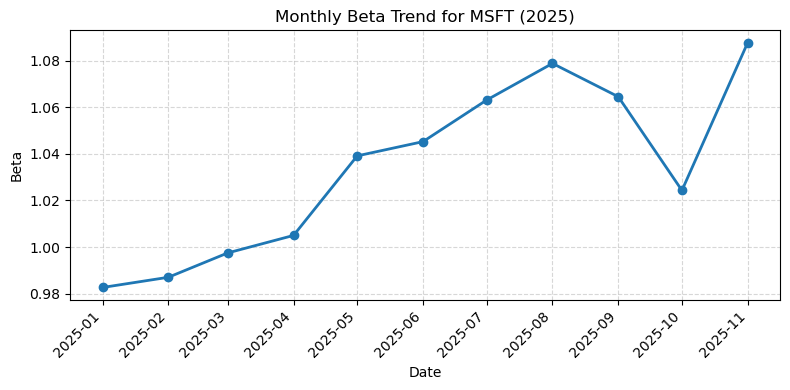

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(dates_2025, monthly_beta, marker='o', linewidth=2)
plt.title("Monthly Beta Trend for MSFT (2025)")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha='right')   
plt.tight_layout()
plt.show()

In [ ]:
# this is fama-french modeling, so simply but we can jsut ignore SMB and HML beta returns because because the multivariate ff3 formula collapses into a CAPM regression formula
# oos1_list is system dependant and only would work on my computer, because this snippet is just the specific fucntions used for this beta estimate (part of a much bigger system )

### Supporting factor graphs showing SMB & HML behavior of MSFT

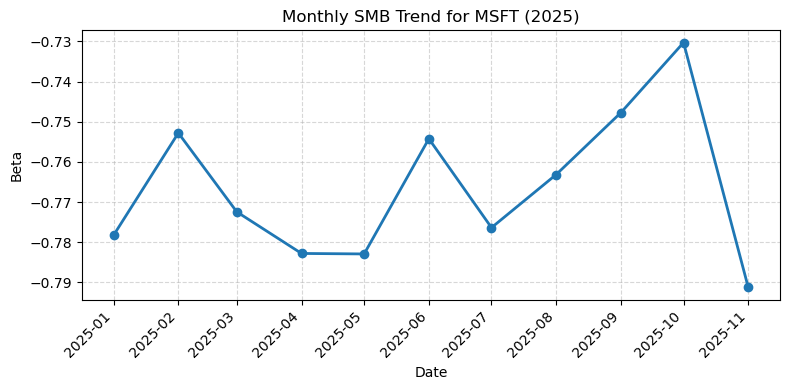

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(dates_2025, monthly_beta_smb, marker='o', linewidth=2)
plt.title("Monthly SMB Trend for MSFT (2025)")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha='right')   
plt.tight_layout()
plt.show()

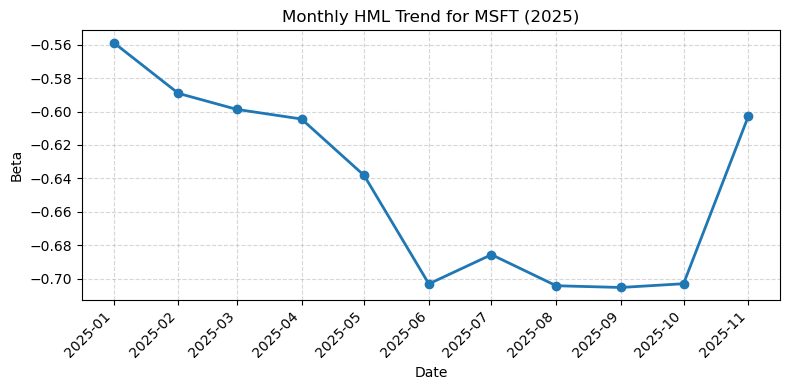

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(dates_2025, monthly_beta_hml, marker='o', linewidth=2)
plt.title("Monthly HML Trend for MSFT (2025)")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha='right')   
plt.tight_layout()
plt.show()